# Wav2Vec2
### Improve model

In [1]:
import os, random, json, math
from pathlib import Path
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.sampler import WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
)

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from transformers import (
    Wav2Vec2Processor,
    Wav2Vec2ForSequenceClassification,
    get_linear_schedule_with_warmup
)

c:\V89\.venv\Lib\site-packages\transformers\utils\generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
c:\V89\.venv\Lib\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
c:\V89\.venv\Lib\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
c:\V89\.venv\Lib\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [ ]:
TRAIN_NPZ_DIR = Path(r"C:\V89\data2\train_npy")
TEST_NPZ_DIR  = Path(r"C:\V89\data_test\test_npy")

TRAIN_CSV = r"C:\V89\Snore_Apnea_Analyze\EDF_RML\data_csv\use_train\train\use_train.csv"
TEST_CSV  = r"C:\V89\Snore_Apnea_Analyze\EDF_RML\data_csv\use_test\test\use_test.csv"

SAVE_DIR  = Path(r"C:\V89\Snore_Apnea_Analyze\EDF_RML\binary_wav2vec2_npy_V1")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
TARGET_SR = 16000
SEGMENT_SECONDS = 5.0
SEG_SAMPLES = int(TARGET_SR * SEGMENT_SECONDS)
BATCH_SIZE = 4
EPOCH5S= 20
LR = 1e-5  # transformer: ควรใช้ LR ต่ำ
VAL_THRESHOLD = 0.50  # threshold สำหรับ class=1 (Apnea) ตอน Val/Test (ปรับได้)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name())

# Label mapping (edit to your taste)
APNEA_TYPES = {"Apnea","Hypopnea","CentralApnea","MixedApnea"}
NON_APNEA_TYPES = {"Snore"}

def map_type_to_label(t: str) -> int:
    if t in APNEA_TYPES: return 1
    if t in NON_APNEA_TYPES: return 0
    # ค่าอื่นที่ไม่อยู่ในเซ็ต: treat as non-apnea (หรือ raise)
    return 0

Device: cuda
GPU: NVIDIA GeForce RTX 4060


In [4]:
df_train_all = pd.read_csv(TRAIN_CSV)
df_test_all  = pd.read_csv(TEST_CSV)

# ต้องมีคอลัมน์: patient_id, segment_index, type, (segment_local_start_sec หรือ start_sec), duration_sec
# สร้าง label
df_train_all = df_train_all.copy()
df_train_all["label"] = df_train_all["type"].map(map_type_to_label).astype(int)

df_test_all = df_test_all.copy()
df_test_all["label"] = df_test_all["type"].map(map_type_to_label).astype(int)

# Split train/val จาก train CSV
train_df, val_df = train_test_split(
    df_train_all, test_size=0.2, stratify=df_train_all["label"], random_state=SEED
)
print("Train size:", len(train_df), "Val size:", len(val_df), "Test size:", len(df_test_all))

Train size: 619 Val size: 155 Test size: 595


In [5]:
def resolve_npz_path(root_dir: Path, pid: int, seg_index: int) -> Path | None:
    fname = f"{int(pid):08d}-100507[{int(seg_index)+1:03d}].npz"
    path = root_dir / fname
    if path.exists():
        return path
    hits = list(root_dir.rglob(f"*{int(pid):08d}*[{int(seg_index)+1:03d}]*.npz"))
    return hits[0] if hits else None

def load_snore_from_npz(npz_path: Path) -> np.ndarray | None:
    try:
        with np.load(npz_path, allow_pickle=False) as data:
            keys_lower = {k.lower(): k for k in data.keys()}
            if "snore" in keys_lower:
                arr = np.asarray(data[keys_lower["snore"]], dtype=np.float32).copy()
                if arr.ndim > 1:
                    arr = arr.reshape(-1)
                return arr
            else:
                return None
    except Exception as e:
        print(f"[load_snore_from_npz] error {npz_path}: {e}")
        return None

def slice_segment(wave: np.ndarray, start_sec: float, dur_sec: float,
                  sr: int = TARGET_SR, fixed_len: int = SEG_SAMPLES) -> np.ndarray | None:
    if wave is None or len(wave) == 0:
        return None
    start = int(max(0.0, float(start_sec)) * sr)
    end = start + int(float(dur_sec) * sr)
    if start >= len(wave):
        return None
    seg = wave[start:min(end, len(wave))]
    if len(seg) <= 0:
        return None
    if len(seg) < fixed_len:
        seg = np.pad(seg, (0, fixed_len - len(seg)), mode="constant")
    else:
        seg = seg[:fixed_len]
    return seg.astype(np.float32) seg = seg[:fixed_len]
    return seg.astype(np.float32)

In [6]:
class W2V2NPZDataset(Dataset):
    def __init__(self, df: pd.DataFrame, npz_root: Path, target_sr=TARGET_SR, seg_seconds=SEGMENT_SECONDS):
        self.df = df.reset_index(drop=True)
        self.root = npz_root
        self.target_sr = target_sr
        self.seg_seconds = seg_seconds

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        try:
            r = self.df.iloc[idx]
            pid = int(r["patient_id"])
            seg_index = int(r["segment_index"])
            start_sec = float(r.get("segment_local_start_sec", r.get("start_sec", 0.0)))
            dur_sec   = min(float(r.get("duration_sec", self.seg_seconds)), self.seg_seconds)

            p = resolve_npz_path(self.root, pid, seg_index)
            if p is None or not p.exists():
                raise FileNotFoundError(f"No file for pid={pid} seg={seg_index}")

            wave = load_snore_from_npz(p)
            seg  = slice_segment(wave, start_sec, dur_sec, sr=self.target_sr, fixed_len=SEG_SAMPLES)
            if seg is None:
                seg = slice_segment(wave, 0.0, self.seg_seconds, sr=self.target_sr, fixed_len=SEG_SAMPLES)
                if seg is None:
                    raise RuntimeError(f"Empty segment for {p}")

            y = int(r["label"])
            return torch.tensor(seg), torch.tensor(y, dtype=torch.long)

        except Exception as e:
            print(f"[Dataset] Skipping index {idx} due to error: {e}")
            return torch.zeros(SEG_SAMPLES, dtype=torch.float32), torch.tensor(0)pe=torch.float32), torch.tensor(0)


In [7]:
PROCESSOR_NAME = "facebook/wav2vec2-base"
processor = Wav2Vec2Processor.from_pretrained(PROCESSOR_NAME)

def collate_w2v2(batch):
    waves, labels = zip(*batch)
    inputs = processor(
        [w.numpy() for w in waves],
        sampling_rate=TARGET_SR,
        return_tensors="pt",
        padding=True,
        max_length=SEG_SAMPLES,
        truncation=True,
    )
    return {
        "input_values": inputs.input_values,
        "attention_mask": inputs.attention_mask if "attention_mask" in inputs else None,
        "labels": torch.stack(labels),
    }


c:\V89\.venv\Lib\site-packages\transformers\configuration_utils.py:381: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


In [8]:
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    PROCESSOR_NAME,
    num_labels=2,
    problem_type="single_label_classification",
).to(device)

for p in model.wav2vec2.feature_extractor.parameters():
    p.requires_grad = False
    p.requires_grad = False

Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'projector.bias', 'projector.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [9]:
# =====================
train_ds = W2V2NPZDataset(train_df, TRAIN_NPZ_DIR)
val_ds   = W2V2NPZDataset(val_df,   TRAIN_NPZ_DIR)
test_ds  = W2V2NPZDataset(df_test_all, TEST_NPZ_DIR)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_w2v2, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_w2v2, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_w2v2, num_workers=0, pin_memory=True)


In [10]:
cls_counts   = np.bincount(train_df["label"].values, minlength=2)
cls_weights  = compute_class_weight(class_weight="balanced", classes=np.array([0,1]), y=train_df["label"].values)
cls_weights_t = torch.tensor(cls_weights, dtype=torch.float32, device=device)
print("Class counts:", cls_counts, "Class weights:", cls_weights_t.cpu().numpy())

criterion = nn.CrossEntropyLoss(weight=cls_weights_t)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
total_steps = EPOCHS * math.ceil(len(train_loader))
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

Class counts: [223 396] Class weights: [1.3878924  0.78156567]


In [11]:
def run_eval(dataloader, threshold=0.5):
    model.eval()
    all_true, all_pred = [], []
    running_loss = 0.0
    with torch.no_grad():
        for batch in dataloader:
            input_values = batch["input_values"].to(device)
            attention_mask = batch["attention_mask"].to(device) if batch["attention_mask"] is not None else None
            labels = batch["labels"].to(device)

            outputs = model(input_values, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            logits = outputs.logits

            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = (probs >= threshold).long()

            running_loss += loss.item()
            all_true.extend(labels.cpu().numpy())
            all_pred.extend(preds.cpu().numpy())
    avg_loss = running_loss / max(1, len(dataloader))
    acc = (np.array(all_true) == np.array(all_pred)).mean()
    f1  = f1_score(all_true, all_pred, average="macro")
    return avg_loss, acc, f1, np.array(all_true), np.array(all_pred)

In [12]:
best_val_f1, best_epoch = 0.0, 0

for epoch in range(1, EPOCHS+1):
    model.train()
    tr_loss, tr_correct, tr_total = 0.0, 0, 0
    tr_true, tr_pred = [], []

    for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]"):
        input_values = batch["input_values"].to(device)
        attention_mask = batch["attention_mask"].to(device) if batch["attention_mask"] is not None else None
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(input_values, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        logits = outputs.logits
        loss.backward()
        optimizer.step()
        scheduler.step()

        tr_loss += loss.item()
        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = (probs >= 0.5).long()
        tr_correct += (preds == labels).sum().item()
        tr_total += labels.size(0)
        tr_true.extend(labels.cpu().numpy()); tr_pred.extend(preds.cpu().numpy())

    train_acc = tr_correct / max(1, tr_total)
    train_f1  = f1_score(tr_true, tr_pred, average="macro")

    val_loss, val_acc, val_f1, _, _ = run_eval(val_loader, threshold=VAL_THRESHOLD)
    print(f"Epoch {epoch:02d} | "
          f"Train Loss {tr_loss/len(train_loader):.4f} Acc {train_acc:.4f} F1 {train_f1:.4f}  ||  "
          f"Val Loss {val_loss:.4f} Acc {val_acc:.4f} F1 {val_f1:.4f}")
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch
        best_model_dir = SAVE_DIR / "wav2vec2_best"
        best_model_dir.mkdir(parents=True, exist_ok=True)
        model.save_pretrained(str(best_model_dir))
        processor.save_pretrained(str(best_model_dir))
        print(f"✅ New best model saved! F1: {best_val_f1:.4f} at epoch {best_epoch}")

final_model_dir = SAVE_DIR / "wav2vec2_final"
final_model_dir.mkdir(parents=True, exist_ok=True)
model.save_pretrained(str(final_model_dir))
processor.save_pretrained(str(final_model_dir))
print(f"\n✅ Final model saved to: {final_model_dir}")
print(f"📊 Training completed! Best validation F1: {best_val_f1:.4f} at epoch {best_epoch}")

Epoch 1/5 [Train]:   0%|          | 0/155 [00:00<?, ?it/s]

Epoch 1/5 [Train]:   0%|          | 0/155 [00:00<?, ?it/s]

c:\V89\.venv\Lib\site-packages\torch\_dynamo\eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch 1/5 [Train]:   0%|          | 0/155 [00:00<?, ?it/s]

c:\V89\.venv\Lib\site-packages\torch\_dynamo\eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


...

c:\V89\.venv\Lib\site-packages\torch\_dynamo\eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch 04 | Train Loss 0.0776 Acc 0.9790 F1 0.9774  ||  Val Loss 0.0769 Acc 0.9742 F1 0.9723


Epoch 5/5 [Train]:   0%|          | 0/155 [00:00<?, ?it/s]

c:\V89\.venv\Lib\site-packages\torch\_dynamo\eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch 05 | Train Loss 0.0593 Acc 0.9871 F1 0.9861  ||  Val Loss 0.0953 Acc 0.9742 F1 0.9723

✅ Final model saved to: C:\V89\Snore_Apnea_Analyze\EDF_RML\binary_wav2vec2_npy_V1\wav2vec2_final
📊 Training completed! Best validation F1: 0.9724 at epoch 1

✅ Final model saved to: C:\V89\Snore_Apnea_Analyze\EDF_RML\binary_wav2vec2_npy_V1\wav2vec2_final
📊 Training completed! Best validation F1: 0.9724 at epoch 1


📊 Test Results
Loss: 0.5342
Accuracy: 0.8437
Macro F1: 0.8024

Classification Report:
               precision    recall  f1-score   support

           0     0.8562    0.9325    0.8927       415
           1     0.8042    0.6389    0.7121       180

    accuracy                         0.8437       595
   macro avg     0.8302    0.7857    0.8024       595
weighted avg     0.8405    0.8437    0.8381       595



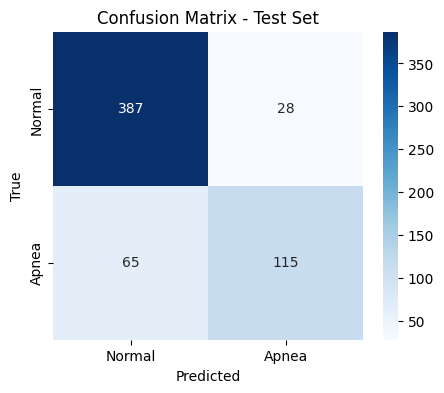

In [15]:
from transformers import Wav2Vec2ForSequenceClassification, Wav2Vec2Processor

# =====================
# 1) Load best model
# =====================
best_model_dir = r"C:\V89\Snore_Apnea_Analyze\EDF_RML\binary_wav2vec2_npy_V1\wav2vec2_final"

processor = Wav2Vec2Processor.from_pretrained(best_model_dir)
model = Wav2Vec2ForSequenceClassification.from_pretrained(best_model_dir).to(device)
model.eval()

# =====================
# 2) Run evaluation
# =====================
test_loss, test_acc, test_f1, y_true, y_pred = run_eval(test_loader, threshold=VAL_THRESHOLD)

print("📊 Test Results")
print(f"Loss: {test_loss:.4f}")
print(f"Accuracy: {test_acc:.4f}")
print(f"Macro F1: {test_f1:.4f}")

# (optional) confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
print("\nClassification Report:\n", classification_report(y_true, y_pred, digits=4))

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal","Apnea"], yticklabels=["Normal","Apnea"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Test Set")
plt.show()


# Test with other data type

In [5]:
import json

with open(r"C:\V89\data\01_annotation.json", "r", encoding="utf-8") as f:
    data = json.load(f)

print("Type:", type(data))
print("Preview:", data if isinstance(data, dict) else data[:3])


Type: <class 'dict'>
Preview: {'record_start': 75454.0, 'awake_intervals': [[81583.0, 81697.0], [81762.0, 81909.0], [81998.0, 82026.0], [82718.0, 82776.0], [83346.0, 83375.0], [84039.0, 84065.0], [85175.0, 85208.0], [85715.0, 85866.0], [88385.0, 88537.0], [90185.0, 90217.0], [92255.0, 92588.0], [92645.0, 92686.0], [93307.0, 93395.0], [93579.0, 93605.0], [93785.0, 93816.0], [94146.0, 94205.0], [95255.0, 95285.0], [95675.0, 95705.0], [100420.0, 100445.0], [102909.0, 102965.0], [104795.0, 104915.0], [105248.0, 116769.0], [105248.0, 116769.0]], 'events': [{'event_type': 'hypo', 'evnet_start': 81888.0, 'event_duration': 41.0, 'sleep_stage': 'W'}, {'event_type': 'hypo', 'evnet_start': 81954.0, 'event_duration': 41.3, 'sleep_stage': 'N1'}, {'event_type': 'hypo', 'evnet_start': 82026.0, 'event_duration': 41.3, 'sleep_stage': 'N1'}, {'event_type': 'hypo', 'evnet_start': 82117.0, 'event_duration': 38.3, 'sleep_stage': 'N2'}, {'event_type': 'hypo', 'evnet_start': 82183.0, 'event_duration': 26.2, 

In [7]:
import os
import json
from collections import Counter

DATA_DIR = r"C:\V89\data"
all_event_types = []
file_event_counts = {}

for fname in os.listdir(DATA_DIR):
    if fname.endswith("_annotation.json"):
        path = os.path.join(DATA_DIR, fname)
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)

        events = data.get("events", [])
        types = [e.get("event_type") for e in events if isinstance(e, dict)]
        types = [t for t in types if t is not None]

        all_event_types.extend(types)
        file_event_counts[fname] = Counter(types)

# Overall distribution
overall_counter = Counter(all_event_types)
print("📊 Overall event_type distribution:")
for lbl, cnt in overall_counter.most_common():
    print(f"{lbl:15s}: {cnt}")

print("\n🔎 Example per file:")
for f, cnts in list(file_event_counts.items())[:5]:
    print(f"{f}: {dict(cnts)}")


📊 Overall event_type distribution:
hypo           : 2676
osa            : 1636

🔎 Example per file:
01_annotation.json: {'hypo': 85, 'osa': 1}
02_annotation.json: {'hypo': 160, 'osa': 414}
03_annotation.json: {'hypo': 174, 'osa': 55}
04_annotation.json: {'hypo': 38}
05_annotation.json: {'hypo': 123, 'osa': 312}


In [16]:

import os
import json
import random
import pandas as pd

DATA_DIR = r"C:\V89\data"
OUT_CSV = r"C:\V89\Snore_Apnea_Analyze\EDF_RML\data_csv\normal_samples.csv"

SEG_LEN = 5.0  # seconds
N_PER_CLASS = 50

random.seed(42)

def merge_intervals(intervals):
    if not intervals:
        return []
    intervals = sorted(intervals, key=lambda x: x[0])
    merged = [intervals[0]]
    for start, end in intervals[1:]:
        last_start, last_end = merged[-1]
        if start <= last_end:
            merged[-1] = (last_start, max(last_end, end))
        else:
            merged.append((start, end))
    return merged

records = []

# ใช้เฉพาะ 5 ไฟล์แรก
for fname in sorted(os.listdir(DATA_DIR))[:5]:
    if not fname.endswith("_annotation.json"):
        continue
    pid = fname.replace("_annotation.json", "")
    wavfile = pid + "_phone.wav"
    path = os.path.join(DATA_DIR, fname)

    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    record_start = data.get("record_start", 0.0)
    events = data.get("events", [])

    # เก็บ event ของคนนี้
    osa_events, hypo_events, intervals = [], [], []
    for ev in events:
        t = ev.get("event_type")
        s = ev.get("evnet_start", 0.0)
        d = ev.get("event_duration", 0.0)
        e = s + d
        if t == "osa":
            osa_events.append((s, d))
        elif t == "hypo":
            hypo_events.append((s, d))
        intervals.append((s, e))

    # หา normal จากช่วงว่าง
    merged = merge_intervals(intervals)
    normal_segments = []
    cur = record_start
    for s, e in merged:
        if cur < s:
            normal_segments.append((cur, s))
        cur = max(cur, e)

    # สร้าง normal chunk ยาว SEG_LEN
    normal_chunks = []
    for (ns, ne) in normal_segments:
        length = ne - ns
        if length >= SEG_LEN:
            n_chunks = int(length // SEG_LEN)
            for c in range(n_chunks):
                seg_start = ns + c * SEG_LEN
                normal_chunks.append((seg_start, SEG_LEN))

    # สุ่มเลือก 50 ต่อ class (ถ้ามีไม่พอ จะเอาทั้งหมดแล้ว warn)
    def sample_events(evlist, label):
        if len(evlist) > N_PER_CLASS:
            evs = random.sample(evlist, N_PER_CLASS)
        else:
            evs = evlist
            print(f"⚠️ {pid} {label} has only {len(evlist)} events (needed {N_PER_CLASS})")
        for s, d in evs:
            records.append({
                "patient": pid,
                "file": wavfile,
                "start": s,
                "duration": min(d, SEG_LEN),  # ตัด event ให้ยาวไม่เกิน SEG_LEN
                "label": label
            })

    def sample_normals(nlist):
        if len(nlist) > N_PER_CLASS:
            evs = random.sample(nlist, N_PER_CLASS)
        else:
            evs = nlist
            print(f"⚠️ {pid} normal has only {len(nlist)} segments (needed {N_PER_CLASS})")
        for s, d in evs:
            records.append({
                "patient": pid,
                "file": wavfile,
                "start": s,
                "duration": d,
                "label": "normal"
            })

    sample_events(osa_events, "osa")
    sample_events(hypo_events, "hypo")
    sample_normals(normal_chunks)

df = pd.DataFrame(records)
df.to_csv(OUT_CSV, index=False)
print(f"✅ Saved balanced dataset with {len(df)} rows -> {OUT_CSV}")
print(df.head(15))



⚠️ 01 osa has only 1 events (needed 50)
✅ Saved balanced dataset with 401 rows -> C:\V89\Snore_Apnea_Analyze\EDF_RML\data_csv\normal_samples.csv
   patient          file     start  duration label
0       01  01_phone.wav   91044.0       5.0   osa
1       01  01_phone.wav  103965.0       5.0  hypo
2       01  01_phone.wav   83006.0       5.0  hypo
3       01  01_phone.wav   82117.0       5.0  hypo
4       01  01_phone.wav   91203.0       5.0  hypo
5       01  01_phone.wav   89959.0       5.0  hypo
6       01  01_phone.wav   86679.0       5.0  hypo
7       01  01_phone.wav   83160.0       5.0  hypo
8       01  01_phone.wav   82754.0       5.0  hypo
9       01  01_phone.wav   98643.0       5.0  hypo
10      01  01_phone.wav   82597.0       5.0  hypo
11      01  01_phone.wav   94895.0       5.0  hypo
12      01  01_phone.wav   82183.0       5.0  hypo
13      01  01_phone.wav  104785.0       5.0  hypo
14      01  01_phone.wav  101972.0       5.0  hypo


In [17]:
df = pd.read_csv(r"C:\V89\Snore_Apnea_Analyze\EDF_RML\data_csv\normal_samples.csv")

In [18]:
df['label'].value_counts()

label
hypo      150
normal    150
osa       101
Name: count, dtype: int64

In [19]:
df

,patient,file,start,duration,label
0,1,01_phone.wav,91044.0,5.0,osa
1,1,01_phone.wav,103965.0,5.0,hypo
2,1,01_phone.wav,83006.0,5.0,hypo
3,1,01_phone.wav,82117.0,5.0,hypo
4,1,01_phone.wav,91203.0,5.0,hypo
...,...,...,...,...,...
396,3,03_phone.wav,101754.7,5.0,normal
397,3,03_phone.wav,100973.4,5.0,normal
398,3,03_phone.wav,88418.9,5.0,normal
399,3,03_phone.wav,79114.0,5.0,normal


# Test ดู

In [2]:
import os
import pandas as pd
import torch
import torchaudio
from transformers import Wav2Vec2Processor, Wav2Vec2ForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

c:\V89\.venv\Lib\site-packages\transformers\utils\generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
c:\V89\.venv\Lib\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
c:\V89\.venv\Lib\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [3]:
from transformers import Wav2Vec2Processor, Wav2Vec2ForSequenceClassification

MODEL_DIR = r"C:\V89\Snore_Apnea_Analyze\EDF_RML\binary_wav2vec2_npy_V1\wav2vec2_best"

# ลองโหลดบน CPU ก่อน ป้องกัน GPU crash
processor = Wav2Vec2Processor.from_pretrained(MODEL_DIR)
model = Wav2Vec2ForSequenceClassification.from_pretrained(MODEL_DIR).to("cpu")
model.eval()
print("✅ Model loaded successfully")

✅ Model loaded successfully


In [9]:
CSV_PATH  = r"C:\V89\Snore_Apnea_Analyze\EDF_RML\data_csv\normal_samples.csv"
WAV_DIR   = r"C:\V89\data"
MODEL_DIR = r"C:\V89\Snore_Apnea_Analyze\EDF_RML\binary_wav2vec2_npy_V1\wav2vec2_best"
TARGET_SR = 16000

In [4]:
import pandas as pd

In [5]:
device = torch.device("cpu")

In [10]:
# =====================
# Load CSV + take 1 row
# =====================
df = pd.read_csv(CSV_PATH)
row = df.iloc[0]   # เอาแค่ sample แรก
wav_path = os.path.join(WAV_DIR, row["file"])

# =====================
# Load audio & slice segment
# =====================
wave, sr = torchaudio.load(wav_path)

# convert stereo -> mono
if wave.shape[0] > 1:
    wave = torch.mean(wave, dim=0, keepdim=True)

# resample if needed
if sr != TARGET_SR:
    wave = torchaudio.transforms.Resample(sr, TARGET_SR)(wave)

# slice segment
start_sample = int(row["start"] * TARGET_SR)
end_sample   = start_sample + int(row["duration"] * TARGET_SR)

if end_sample > wave.shape[1]:
    end_sample = wave.shape[1]

segment = wave[:, start_sample:end_sample]

# pad if shorter than duration
need_len = int(row["duration"] * TARGET_SR)
if segment.shape[1] < need_len:
    pad = need_len - segment.shape[1]
    segment = torch.nn.functional.pad(segment, (0, pad))

# =====================
# Run model
# =====================
inputs = processor(segment.squeeze().numpy(), sampling_rate=TARGET_SR, return_tensors="pt", padding=True)
with torch.no_grad():
    logits = model(inputs.input_values.to(device)).logits
    probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]
    pred = int(torch.argmax(torch.tensor(probs)))

print(f"Ground Truth: {row['label']}  → mapped: {'Apnea(1)' if row['label'] in ['osa','hypo'] else 'Normal(0)'}")
print(f"Prediction  : {pred} (0=Normal, 1=Apnea)")
print(f"Probabilities: Normal={probs[0]:.3f}, Apnea={probs[1]:.3f}")

Ground Truth: osa  → mapped: Apnea(1)
Prediction  : 0 (0=Normal, 1=Apnea)
Probabilities: Normal=0.921, Apnea=0.079


Classification Report (0=Normal, 1=Apnea):

              precision    recall  f1-score   support

      Normal       0.43      1.00      0.60        43
       Apnea       0.00      0.00      0.00        57

    accuracy                           0.43       100
   macro avg       0.21      0.50      0.30       100
weighted avg       0.18      0.43      0.26       100



c:\V89\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\V89\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\V89\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


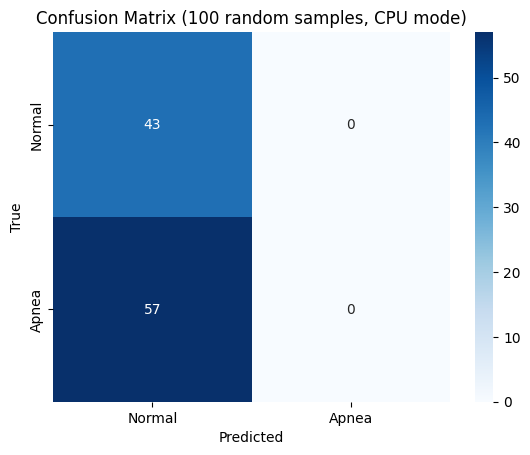

In [2]:
import pandas as pd, os, torchaudio, torch
from transformers import Wav2Vec2Processor, Wav2Vec2ForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# =====================
# Config
# =====================
CSV_PATH  = r"C:\V89\Snore_Apnea_Analyze\EDF_RML\data_csv\normal_samples.csv"
WAV_DIR   = r"C:\V89\data"
MODEL_DIR = r"C:\V89\Snore_Apnea_Analyze\EDF_RML\binary_wav2vec2_npy_V1\wav2vec2_best"
TARGET_SR = 16000
device = torch.device("cpu")   # ✅ force CPU

# =====================
# Load model
# =====================
processor = Wav2Vec2Processor.from_pretrained(MODEL_DIR)
model = Wav2Vec2ForSequenceClassification.from_pretrained(MODEL_DIR).to(device)
model.eval()

# =====================
# Load CSV
# =====================
df = pd.read_csv(CSV_PATH)

# Map hypo/osa -> Apnea(1), normal -> 0
df["mapped_label"] = df["label"].apply(lambda x: 1 if x in ["osa", "hypo"] else 0)

# เลือก subset 100 แถว (หรือทั้งหมดก็ได้)
sample_df = df.sample(n=min(100, len(df)), random_state=42).reset_index(drop=True)

# =====================
# Helper: load segment
# =====================
def load_audio_segment(wav_path, start, duration, target_sr=16000):
    wav, sr = torchaudio.load(wav_path)
    if wav.shape[0] > 1:
        wav = torch.mean(wav, dim=0, keepdim=True)
    if sr != target_sr:
        wav = torchaudio.transforms.Resample(sr, target_sr)(wav)

    start_sample = int(start * target_sr)
    end_sample   = start_sample + int(duration * target_sr)

    if start_sample >= wav.shape[1]:
        return torch.zeros(int(duration * target_sr))

    if end_sample > wav.shape[1]:
        end_sample = wav.shape[1]

    segment = wav[:, start_sample:end_sample]
    need_len = int(duration * target_sr)
    if segment.shape[1] < need_len:
        segment = torch.nn.functional.pad(segment, (0, need_len - segment.shape[1]))
    return segment.squeeze(0).cpu()

# =====================
# Inference loop
# =====================
all_true, all_pred = [], []

for _, row in sample_df.iterrows():
    wav_path = os.path.join(WAV_DIR, row["file"])
    segment = load_audio_segment(wav_path, row["start"], row["duration"], target_sr=TARGET_SR)

    wave_np = segment.numpy().astype("float32")
    inputs = processor(wave_np, sampling_rate=TARGET_SR, return_tensors="pt")

    with torch.no_grad():
        logits = model(inputs.input_values.to(device)).logits
        pred = torch.argmax(logits, dim=-1).cpu().item()

    all_true.append(row["mapped_label"])
    all_pred.append(pred)

# =====================
# Report
# =====================
print("Classification Report (0=Normal, 1=Apnea):\n")
print(classification_report(all_true, all_pred, target_names=["Normal","Apnea"]))

cm = confusion_matrix(all_true, all_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal","Apnea"], yticklabels=["Normal","Apnea"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (100 random samples, CPU mode)")
plt.show()
